# Metallicity Analysis

In this note, I want to discuss the impact of the metallicity.

The goal is making the plot using the metallicity as a function of redshift.

To do that, I need to calculate the stellar metallicity throughout all snapshots.

In [3]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})

## Getting the mean metallicity as a function of redshift

In [4]:

SNAPDIR = "/orcd/data/mvogelsb/005/Lumina/Lumina_above_z_4p75/snapshots"
SNAP = 11

# redshift from the virtual snapshot header
with h5py.File(os.path.join(SNAPDIR, f"snap_{SNAP:03d}.hdf5"), "r") as f:
    z_snap = float(f["Header"].attrs["Redshift"])
    a_snap = float(f["Header"].attrs["Time"])

# stellar fields
with h5py.File(os.path.join(SNAPDIR, "PartType4", f"PartType4_{SNAP:03d}.hdf5"), "r") as f:
    Z      = f["GFM_Metallicity"][:]
    a_form = f["GFM_StellarFormationTime"][:]
    M      = f["Masses"][:]

is_star = a_form > 0                     # drop GFM wind particles
Zs, Ms  = Z[is_star], M[is_star]
assert a_form[is_star].max() <= a_snap * (1 + 1e-6)

print(f"snap {SNAP:03d}   z = {z_snap:.4f}   N_star = {Zs.size}   N_wind = {(~is_star).sum()}")
print(f"Z min            = {Zs.min():.4e}")
print(f"Z mean           = {Zs.mean():.4e}")
print(f"Z mean (mass-wt) = {np.average(Zs, weights=Ms):.4e}")
print(f"Z median         = {np.median(Zs):.4e}")
print(f"Z max            = {Zs.max():.4e}")

snap 011   z = 22.9653   N_star = 1   N_wind = 77
Z min            = 0.0000e+00
Z mean           = 0.0000e+00
Z mean (mass-wt) = 0.0000e+00
Z median         = 0.0000e+00
Z max            = 0.0000e+00


In [5]:

SNAPDIR = "/orcd/data/mvogelsb/005/Lumina/Lumina_above_z_4p75/snapshots"

snaps = sorted(int(re.search(r"snap_(\d{3})\.hdf5$", p).group(1))
               for p in glob.glob(os.path.join(SNAPDIR, "snap_*.hdf5")))

rows = []
for snap in snaps:
    with h5py.File(os.path.join(SNAPDIR, f"snap_{snap:03d}.hdf5"), "r") as f:
        z_snap = float(f["Header"].attrs["Redshift"])
        a_snap = float(f["Header"].attrs["Time"])

    with h5py.File(os.path.join(SNAPDIR, "PartType4", f"PartType4_{snap:03d}.hdf5"), "r") as f:
        Z      = f["GFM_Metallicity"][:]
        a_form = f["GFM_StellarFormationTime"][:]
        M      = f["Masses"][:]

    is_star = a_form > 0                  # drop GFM wind particles
    Zs, Ms  = Z[is_star], M[is_star]
    n = Zs.size

    r = {
        "snap":       snap,
        "redshift":   z_snap,
        "a":          a_snap,
        "N_star":     n,
        "N_wind":     int((~is_star).sum()),
        "Z_min":      Zs.min()                     if n else np.nan,
        "Z_mean":     Zs.mean()                    if n else np.nan,
        "Z_mean_mw":  np.average(Zs, weights=Ms)   if n else np.nan,
        "Z_median":   np.median(Zs)                if n else np.nan,
        "Z_max":      Zs.max()                     if n else np.nan,
        "aform_ok":   bool(a_form[is_star].max() <= a_snap * (1 + 1e-6)) if n else True,
    }
    rows.append(r)
    print(f"snap {snap:03d}  z = {z_snap:7.4f}  N_star = {n:>12,d}  "
          f"Z_min = {r['Z_min']:.4e}  Z_mean = {r['Z_mean']:.4e}  "
          f"Z_mean_mw = {r['Z_mean_mw']:.4e}  Z_median = {r['Z_median']:.4e}  "
          f"Z_max = {r['Z_max']:.4e}", flush=True)

df = pd.DataFrame(rows).set_index("snap")
df.to_csv('Z_above4p75.csv', index=False)

NameError: name 're' is not defined

In [13]:

SNAPDIR = "/orcd/data/mvogelsb/005/Lumina/Lumina_below_z_4p75/snapshots"

snaps = sorted(int(re.search(r"snap_(\d{3})\.hdf5$", p).group(1))
               for p in glob.glob(os.path.join(SNAPDIR, "snap_*.hdf5")))

rows = []
for snap in snaps:
    with h5py.File(os.path.join(SNAPDIR, f"snap_{snap:03d}.hdf5"), "r") as f:
        z_snap = float(f["Header"].attrs["Redshift"])
        a_snap = float(f["Header"].attrs["Time"])

    with h5py.File(os.path.join(SNAPDIR, "PartType4", f"PartType4_{snap:03d}.hdf5"), "r") as f:
        Z      = f["GFM_Metallicity"][:]
        a_form = f["GFM_StellarFormationTime"][:]
        M      = f["Masses"][:]

    is_star = a_form > 0                  # drop GFM wind particles
    Zs, Ms  = Z[is_star], M[is_star]
    n = Zs.size

    r = {
        "snap":       snap,
        "redshift":   z_snap,
        "a":          a_snap,
        "N_star":     n,
        "N_wind":     int((~is_star).sum()),
        "Z_min":      Zs.min()                     if n else np.nan,
        "Z_mean":     Zs.mean()                    if n else np.nan,
        "Z_mean_mw":  np.average(Zs, weights=Ms)   if n else np.nan,
        "Z_median":   np.median(Zs)                if n else np.nan,
        "Z_max":      Zs.max()                     if n else np.nan,
        "aform_ok":   bool(a_form[is_star].max() <= a_snap * (1 + 1e-6)) if n else True,
    }
    rows.append(r)
    print(f"snap {snap:03d}  z = {z_snap:7.4f}  N_star = {n:>12,d}  "
          f"Z_min = {r['Z_min']:.4e}  Z_mean = {r['Z_mean']:.4e}  "
          f"Z_mean_mw = {r['Z_mean_mw']:.4e}  Z_median = {r['Z_median']:.4e}  "
          f"Z_max = {r['Z_max']:.4e}", flush=True)

df = pd.DataFrame(rows).set_index("snap")
df.to_csv('Z_below4p75.csv', index=False)

snap 126  z =  4.4952  N_star =  504,584,862  Z_min = -3.5010e-06  Z_mean = 9.6013e-03  Z_mean_mw = 9.7572e-03  Z_median = 4.6794e-03  Z_max = 1.7708e-01
snap 131  z =  4.2489  N_star =  641,842,493  Z_min = -3.7327e-06  Z_mean = 1.0548e-02  Z_mean_mw = 1.0708e-02  Z_median = 5.5969e-03  Z_max = 2.0260e-01
snap 136  z =  4.0042  N_star =  824,082,201  Z_min = -3.7327e-06  Z_mean = 1.1579e-02  Z_mean_mw = 1.1737e-02  Z_median = 6.5787e-03  Z_max = 2.2280e-01
snap 139  z =  3.8628  N_star =  953,987,467  Z_min = -1.4687e-05  Z_mean = 1.2186e-02  Z_mean_mw = 1.2340e-02  Z_median = 7.1525e-03  Z_max = 2.2280e-01
snap 141  z =  3.7526  N_star = 1,069,947,628  Z_min = -1.4687e-05  Z_mean = 1.2656e-02  Z_mean_mw = 1.2805e-02  Z_median = 7.5998e-03  Z_max = 2.2280e-01
snap 144  z =  3.6316  N_star = 1,214,084,173  Z_min = -1.4687e-05  Z_mean = 1.3180e-02  Z_mean_mw = 1.3324e-02  Z_median = 8.0942e-03  Z_max = 2.2280e-01
snap 146  z =  3.5008  N_star = 1,392,628,393  Z_min = -1.4687e-05  Z_mean

,redshift,a,N_star,N_wind,Z_min,Z_mean,Z_mean_mw,Z_median,Z_max,aform_ok
snap,,,,,,,,,,
126,4.495169,0.181978,504584862,244446490,-0.000004,0.009601,0.009757,0.004679,0.177079,True
131,4.248936,0.190515,641842493,268836685,-0.000004,0.010548,0.010708,0.005597,0.202596,True
136,4.004168,0.199833,824082201,286153388,-0.000004,0.011579,0.011737,0.006579,0.222801,True
139,3.862821,0.205642,953987467,292751941,-0.000015,0.012186,0.012340,0.007153,0.222801,True
141,3.752623,0.210410,1069947628,295352883,-0.000015,0.012656,0.012805,0.007600,0.222801,True
144,3.631633,0.215907,1214084173,297313449,-0.000015,0.013180,0.013324,0.008094,0.222801,True
146,3.500808,0.222182,1392628393,298204110,-0.000015,0.013764,0.013903,0.008636,0.222801,True
150,3.365332,0.229078,1605244160,296853919,-0.000015,0.014365,0.014496,0.009198,0.222801,True
152,3.250140,0.235286,1811366358,300059703,-0.000015,0.014862,0.014981,0.009669,0.222801,True


## Read the metallicity plot and use it

In [6]:
df_above = pd.read_csv('Z_above4p75.csv')
df_below = pd.read_csv('Z_below4p75.csv')
df = pd.concat([df_above, df_below], ignore_index=True)
#df

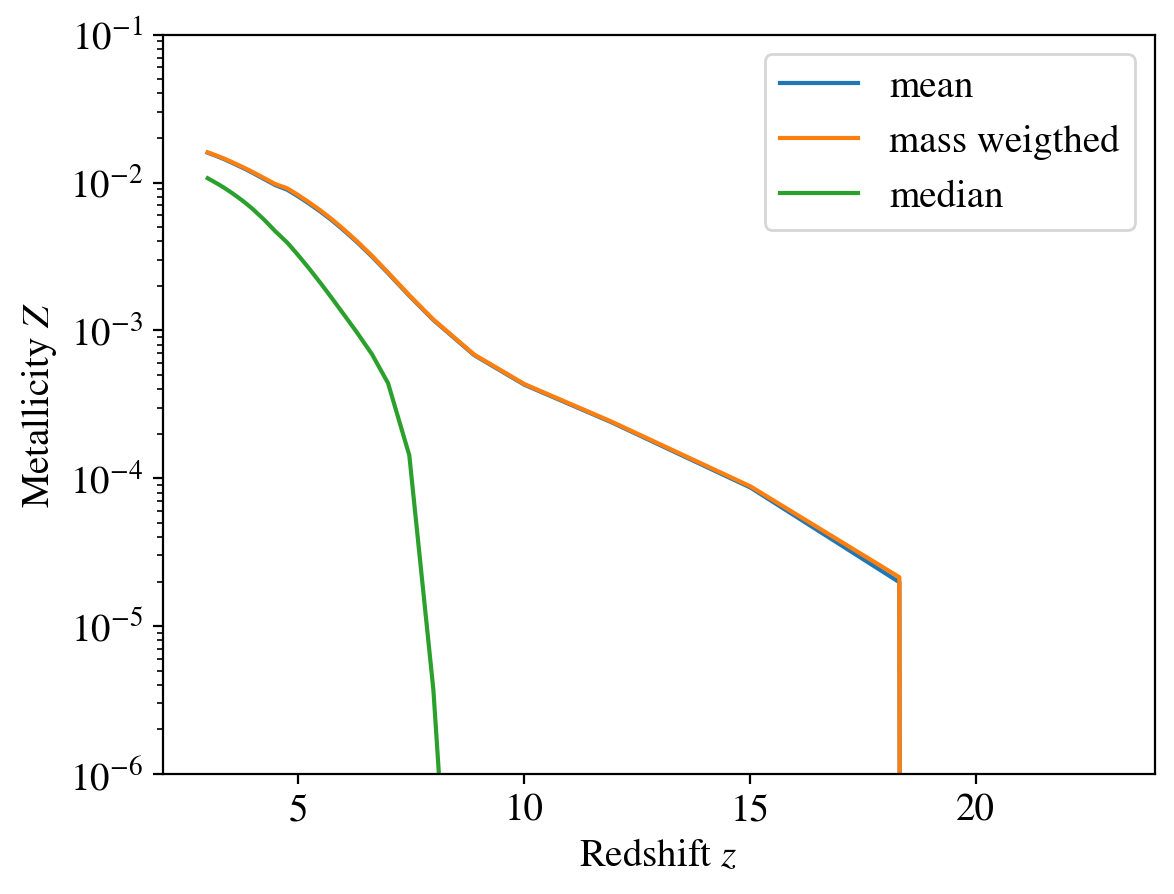

In [13]:
plt.plot(df["redshift"], df["Z_mean"], label="mean")
plt.plot(df["redshift"], df["Z_mean_mw"], label="mass weigthed")
plt.plot(df["redshift"], df["Z_median"], label="median")
plt.xlabel(r"Redshift $z$")
plt.ylabel(r"Metallicity $Z$")
plt.yscale("log")
plt.ylim(1.0e-6, 0.1)
plt.legend()

---
## Dummy Part

In [8]:
# time-integrate once per tabulated metallicity -> shape (N_Z, Nfreq)
N_all     = np.array([get_spec(Z)[1] for Z in spec.Metallicity])
logZ_grid = np.log10(spec.Metallicity)

def N_nu_at(Z):
    """Time-integrated photons/Hz/baryon at arbitrary Z, linear in log Z; clamped to the grid."""
    lz = np.log10(max(Z, spec.Metallicity[0]))           # Z <= 0 or below grid -> lowest grid point
    lz = np.clip(lz, logZ_grid[0], logZ_grid[-1])
    j  = np.clip(np.searchsorted(logZ_grid, lz) - 1, 0, len(logZ_grid) - 2)
    w  = (lz - logZ_grid[j]) / (logZ_grid[j+1] - logZ_grid[j])
    return (1 - w) * N_all[j] + w * N_all[j+1]

band = (freq >= NU_LYMAN_ALPHA) & (freq <= NU_LYMAN_LIMIT)
df["N_Lyband"] = [np.trapezoid(N_nu_at(Z)[band], freq[band]) for Z in df["Z_mean_mw"]]
df[["redshift", "Z_mean_mw", "N_Lyband"]]

NameError: name 'spec' is not defined

In [18]:
df

,redshift,a,N_star,N_wind,Z_min,Z_mean,Z_mean_mw,Z_median,Z_max,aform_ok,Z_new
0,22.965338,0.041727,1,77,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,True,NaN
1,18.312636,0.051780,2027,26857,-7.708502e-17,0.000020,0.000021,0.000000e+00,0.001982,True,NaN
2,15.015599,0.062439,61865,603902,-3.263220e-11,0.000086,0.000088,0.000000e+00,0.006318,True,NaN
3,11.930960,0.077334,1157137,7266590,-3.546530e-09,0.000240,0.000242,0.000000e+00,0.015546,True,NaN
4,10.014035,0.090793,5922048,23080564,-1.234196e-08,0.000428,0.000433,2.934480e-22,0.038632,True,NaN
5,8.896696,0.101044,14151514,39286430,-2.645651e-08,0.000680,0.000687,2.373005e-10,0.076640,True,NaN
6,7.995214,0.111170,27838410,58112667,-2.645651e-08,0.001174,0.001184,3.689566e-06,0.118026,True,NaN
7,7.461845,0.118178,41543142,73484265,-2.645651e-08,0.001713,0.001728,1.427796e-04,0.118026,True,NaN
8,6.990571,0.125148,59690633,91185985,-2.645651e-08,0.002437,0.002463,4.399138e-04,0.118026,True,NaN
9,6.632521,0.131018,79244028,107438661,-2.645651e-08,0.003162,0.003203,6.914466e-04,0.126348,True,NaN
